# RamanBench — Exploring Precomputed Results

This notebook explores the precomputed v0.1 results in detail.

## Ecosystem

| Resource | Link |
|---|---|
| **raman-data** | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/) |
| **raman-bench** | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Leaderboard** | [HuggingFace](https://huggingface.co/spaces/ml-lab-htw/RamanBench) |
| **Paper** | [arXiv TBD](https://arxiv.org/abs/TBD) |

In [1]:
from raman_bench import Leaderboard
import pandas as pd
import matplotlib.pyplot as plt

lb = Leaderboard.from_precomputed()

In [2]:
# Overall ranking
print('=== Overall Leaderboard ===')
lb.rank()

=== Overall Leaderboard ===


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558,0.75,4.8,23.0,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529,0.71,5.5,27.3,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443,0.62,6.5,33.3,39.9,130.3
3,4,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402,0.54,8.1,44.0,77.6,146.4
4,5,MITRA,MITRA,Tabular Foundation,1312,0.42,10.3,49.5,827.4,626.5
5,6,ARSENAL,ARSENAL,TS Classification,1240,0.42,10.4,58.3,2876.0,2790.3
6,7,REZERONET,ReZeroNet,Raman-Specific,1133,0.39,10.3,45.2,44.6,23.1
7,8,ROCKET,ROCKET,TS Classification,1244,0.38,10.4,55.5,1270.3,140.5
8,9,TABDPT,TabDPT,Tabular Foundation,1136,0.30,12.5,52.9,12.3,80.2
9,10,LR,Logistic Reg.,Traditional ML,1002,0.27,14.6,53.3,37.2,41.2


In [3]:
# Classification vs Regression
print('=== Classification Top 10 ===')
display(lb.rank('classification').head(10))

print('=== Regression Top 10 ===')
display(lb.rank('regression').head(10))

=== Classification Top 10 ===


,Rank,model,Model,Category,F1,Bal. Acc.,Accuracy,MCC,Avg Rank,Score,Improvability %,# Datasets,Elo
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,82.9%,83.7%,84.1%,70.5%,6.0,0.69,34.8,21,1454
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,82.4%,83.2%,83.5%,69.4%,7.0,0.66,38.9,21,1397
2,3,TABICL,TabICL,Tabular Foundation,82.5%,83.3%,83.9%,70.3%,7.7,0.60,42.6,21,1360
3,4,REZERONET,ReZeroNet,Raman-Specific,82.0%,83.0%,83.5%,69.8%,8.3,0.52,48.2,21,1338
4,5,ARSENAL,ARSENAL,TS Classification,80.7%,81.6%,82.2%,67.7%,10.4,0.42,58.3,21,1236
5,6,REALTABPFN-V2,TabPFN v2,Tabular Foundation,80.9%,81.7%,82.8%,69.8%,10.5,0.41,62.6,21,1256
6,7,ROCKET,ROCKET,TS Classification,81.4%,81.5%,82.2%,68.0%,10.4,0.38,55.5,21,1257
7,8,DEEPCNN,DeepCNN,Raman-Specific,79.0%,79.5%,80.0%,63.6%,12.1,0.38,52.2,21,1181
8,9,RAMANNET,RamanNet,Raman-Specific,77.9%,77.9%,79.6%,62.8%,13.2,0.33,59.1,21,1167
9,10,MITRA,MITRA,Tabular Foundation,78.0%,79.3%,79.9%,64.0%,13.4,0.33,66.5,21,1140


=== Regression Top 10 ===


,Rank,model,Model,Category,R²,RMSE,MAE,Avg Rank,Score,Improvability %,# Datasets,Elo
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,0.67,10.8,8.0,3.6,0.81,11.3,129,1607
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,0.67,10.4,7.6,3.9,0.77,15.7,129,1580
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,0.60,10.9,7.8,5.7,0.67,25.4,129,1445
3,4,TABICL,TabICL,Tabular Foundation,0.60,10.8,7.8,5.3,0.64,24.0,129,1465
4,5,MITRA,MITRA,Tabular Foundation,0.60,11.2,8.3,7.2,0.51,32.5,129,1338
5,6,TABDPT,TabDPT,Tabular Foundation,-2.20,12.2,8.7,11.7,0.28,41.2,129,1122
6,7,REZERONET,ReZeroNet,Raman-Specific,0.37,11.9,8.9,12.3,0.26,42.3,129,1092
7,8,PLS,PLS,Traditional ML,-0.41,14.1,10.3,14.6,0.21,45.8,129,1040
8,9,REALMLP,RealMLP,Deep Learning,-4.71,12.2,9.0,12.7,0.21,44.0,129,1115
9,10,LR,Logistic Reg.,Traditional ML,-0.72,16.9,12.1,15.1,0.20,48.0,129,1016


In [5]:
# Dataset catalog
import importlib.resources
import pandas as pd

ref = importlib.resources.files("raman_bench") / "data" / "precomputed" / "datasets.csv"
with importlib.resources.as_file(ref) as p:
    datasets_df = pd.read_csv(p)
print(f"{len(datasets_df)} datasets")
datasets_df.head(10)


77 datasets


,dataset_id,Dataset,Domain,Task,Samples,Features,Classes / Targets,License
0,ht_raman_bio_catalysis_axp,Bio-Catalysis Monitoring of AXP,Biological,Regression,344,2048,4,CC BY 4.0
1,bioprocess_analytes_anton_532,Bioprocess Analytes Anton 532,Biological,Regression,270,1601,3,CC BY 4.0
2,bioprocess_analytes_anton_785,Bioprocess Analytes Anton 785,Biological,Regression,270,1001,3,CC BY 4.0
3,ecoli_metabolites,Bioprocess Analytes E. Coli Metabolites,Biological,Regression,1920,594,2,CC BY 4.0
4,bioprocess_analytes_kaiser,Bioprocess Analytes Kaiser,Biological,Regression,134,5472,3,CC BY 4.0
5,bioprocess_analytes_metrohm,Bioprocess Analytes Metrohm,Biological,Regression,399,1875,3,CC BY 4.0
6,bioprocess_analytes_mettler_toledo,Bioprocess Analytes Mettler Toledo,Biological,Regression,275,2901,3,CC BY 4.0
7,bioprocess_analytes_tec5,Bioprocess Analytes Tec5,Biological,Regression,395,2911,3,CC BY 4.0
8,bioprocess_analytes_timegate,Bioprocess Analytes Timegate,Biological,Regression,133,486,3,CC BY 4.0
9,bioprocess_analytes_tornado,Bioprocess Analytes Tornado,Biological,Regression,385,3001,3,CC BY 4.0


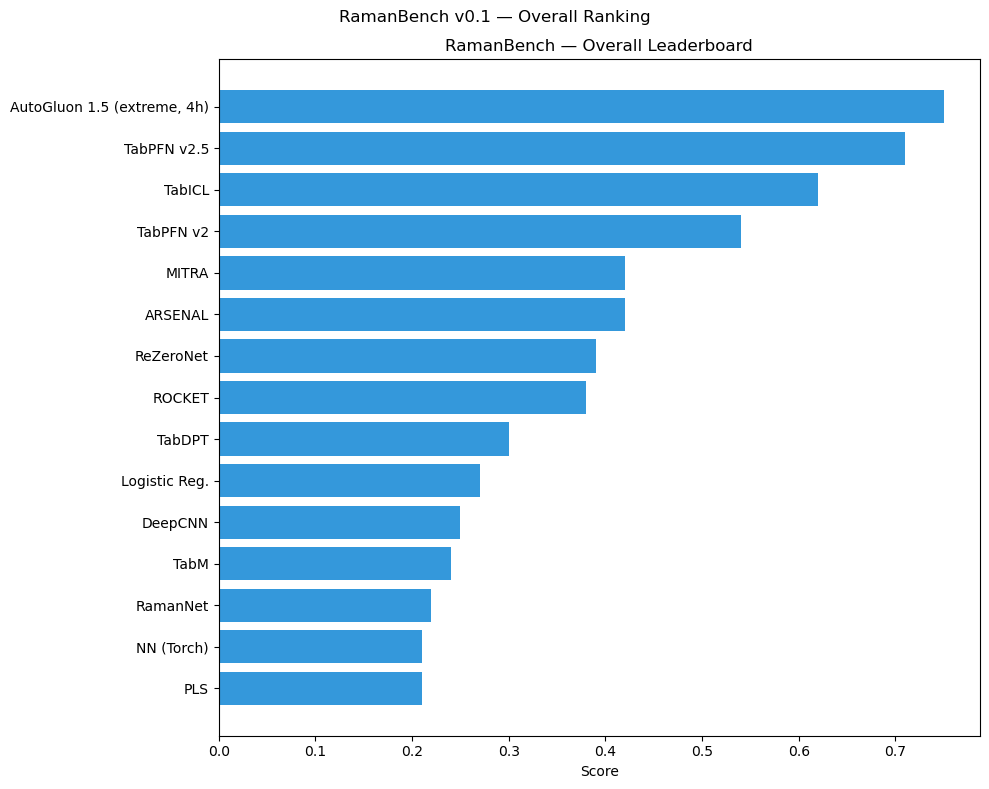

In [6]:
# Plot
fig = lb.plot(task="overall", n_top=15)
plt.suptitle("RamanBench v0.1 — Overall Ranking")
plt.tight_layout()
plt.show()
